# U10 — Feature Engineering (Part 1): Lab

### Real-world brief: building features for a churn-prediction model

EDA (U9) told you *what's* in the data and *what's wrong* with it. Now you turn those insights into **features a model can learn from**: aggregate raw transactions into customer signals, fix skew, bucket and encode, and engineer domain features like **RFM** (Recency, Frequency, Monetary).

**Resources provided:** `ecommerce_customers.csv` (customers) and `transactions.xlsx` (orders). Keep them in the same folder as this notebook (in Colab, upload via the Files panel).

_Day 5 · Phase C — Data Engineering & Preparation._

#objectives

By the end of this lab you will be able to:

Aggregate transaction-level data into customer-level features (RFM)

Transform skewed numerics with a log transform and bucket values with binning

Build ratio and interaction features while guarding against divide-by-zero

Extract datetime features (tenure, recency, cyclical encoding) from raw dates

Encode categoricals (including high-cardinality), and assemble a leak-free feature matrix

#how to use this lab

Worked demo cells teach the pattern. LAB EXERCISE cells (🧪) are real engineering tasks — replace each `# YOUR CODE HERE`. Run top to bottom with **Shift + Enter**.

We use a fixed **analysis snapshot date** of `2024-06-30` (the day the data was pulled) so that recency / tenure are computed consistently — exactly as you would in production.

In [1]:
# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> <NA>) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

SNAPSHOT = pd.Timestamp('2024-06-30')   # the day the data was pulled

cust = pd.read_csv('ecommerce_customers.csv',
                   parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
tx = pd.read_excel('transactions.xlsx', parse_dates=['order_date'])
print('customers:', cust.shape, '| transactions:', tx.shape)
tx.head()

customers: (2500, 15) | transactions: (8152, 4)


,customer_id,order_date,amount,category
0,CUST00003,2023-05-22,39.17,Fashion
1,CUST00004,2022-07-02,2.74,Home
2,CUST00005,2022-09-18,26.27,Electronics
3,CUST00005,2023-04-07,33.48,Fashion
4,CUST00005,2023-08-04,56.41,Fashion


#1. Aggregate transactions → customer features (RFM)

The richest features often don't exist yet — you build them by **aggregating raw events**. This is the core of real feature engineering.

In [3]:
# -----------------------------------------------------------
# 🔹 1A. ROLL UP ORDER-LEVEL ROWS TO ONE ROW PER CUSTOMER
# -----------------------------------------------------------
rfm = tx.groupby('customer_id').agg(
    frequency=('amount', 'size'),                 # F: how many orders
    monetary=('amount', 'sum'),                   # M: total spent
    avg_order_value=('amount', 'mean'),           # typical basket
    last_order=('order_date', 'max'),
    n_categories=('category', 'nunique'),         # breadth of interest
).reset_index()
# R: recency = days since last order, measured from the snapshot
rfm['recency_days'] = (SNAPSHOT - rfm['last_order']).dt.days
rfm[['customer_id', 'frequency', 'monetary', 'avg_order_value',
     'recency_days', 'n_categories']].head()

,customer_id,frequency,monetary,avg_order_value,recency_days,n_categories
0,CUST00003,1,39.17,39.17,405,1
1,CUST00004,1,2.74,2.74,729,1
2,CUST00005,4,133.80,33.45,15,3
3,CUST00006,1,23.36,23.36,45,1
4,CUST00007,2,73.70,36.85,684,2


In [4]:
# -----------------------------------------------------------
# 🔹 1B. MERGE THE NEW FEATURES BACK ONTO THE CUSTOMER TABLE
# -----------------------------------------------------------
df = cust.merge(rfm.drop(columns='last_order'), on='customer_id', how='left')
# customers with no transactions -> fill sensible defaults
df['frequency'] = df['frequency'].fillna(0)
df['monetary'] = df['monetary'].fillna(0)
df['n_categories'] = df['n_categories'].fillna(0)
# never ordered -> recency is 'infinitely' stale: cap at customer tenure
df['recency_days'] = df['recency_days'].fillna(9999)
print('Merged shape:', df.shape)
df[['customer_id', 'frequency', 'monetary', 'recency_days', 'is_churned']].head()

Merged shape: (2500, 20)


,customer_id,frequency,monetary,recency_days,is_churned
0,CUST00001,0.0,0.00,9999.0,0
1,CUST00002,0.0,0.00,9999.0,1
2,CUST00003,1.0,39.17,405.0,0
3,CUST00004,1.0,2.74,729.0,0
4,CUST00005,4.0,133.80,15.0,0


#### 🧪 LAB EXERCISE 1 — Add an 'inter-order gap' feature

A useful behavioural signal is how *often* a customer orders.
1. From `tx`, compute each customer's **active span** = days between their first and last order.
2. Build `avg_days_between_orders` = active span ÷ (frequency − 1), guarding against divide-by-zero (customers with 0 or 1 order).
3. Merge it onto `df` and show `.head()`.

In [5]:
agg_dates = tx.groupby('customer_id')['order_date'].agg(['min','max'])
agg_dates['active_span_days'] = (agg_dates['max'] - agg_dates['min']).dt.days

# Join with rfm to get frequency
rfm_with_span = rfm.merge(agg_dates.drop(columns=['min','max']), on='customer_id', how='left')

# Handle cases where frequency is 0 or 1 (to avoid division by zero or negative)
rfm_with_span['avg_days_between_orders'] = rfm_with_span.apply(
    lambda row: row['active_span_days'] / (row['frequency'] - 1) if row['frequency'] > 1 else np.nan,
    axis=1
)

# Merge onto df and show head
df = df.merge(rfm_with_span[['customer_id', 'active_span_days', 'avg_days_between_orders']],
              on='customer_id', how='left')
display(df[['customer_id', 'frequency', 'active_span_days', 'avg_days_between_orders']].head())

,customer_id,frequency,active_span_days,avg_days_between_orders
0,CUST00001,0.0,NaN,NaN
1,CUST00002,0.0,NaN,NaN
2,CUST00003,1.0,0.0,NaN
3,CUST00004,1.0,0.0,NaN
4,CUST00005,4.0,636.0,212.0


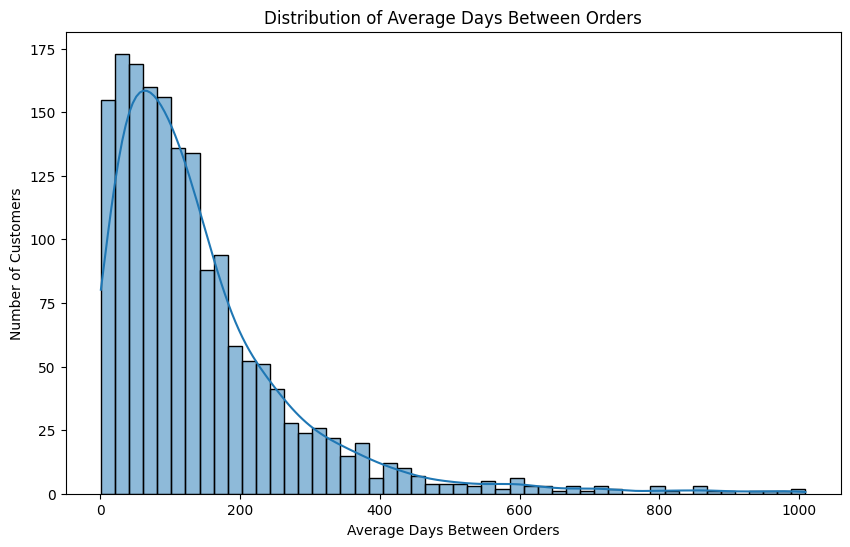

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['avg_days_between_orders'].dropna(), bins=50, kde=True)
plt.title('Distribution of Average Days Between Orders')
plt.xlabel('Average Days Between Orders')
plt.ylabel('Number of Customers')
plt.show()

#2. Numeric transforms — fixing skew

skew before: 1.73
skew after : -1.12


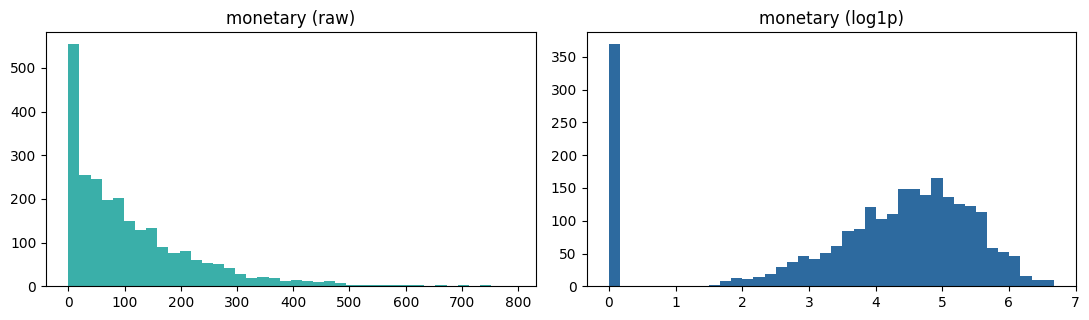

In [8]:
# -----------------------------------------------------------
# 🔹 2A. LOG-TRANSFORM A RIGHT-SKEWED COLUMN
# -----------------------------------------------------------
# EDA showed 'monetary' (total spend) is right-skewed. log1p compresses
# the long tail so big spenders don't dominate the model.
df['monetary_log'] = np.log1p(df['monetary'])   # log1p handles 0 safely
print('skew before:', round(df['monetary'].skew(), 2))
print('skew after :', round(df['monetary_log'].skew(), 2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].hist(df['monetary'], bins=40, color='#3AAFA9'); ax[0].set_title('monetary (raw)')
ax[1].hist(df['monetary_log'], bins=40, color='#2D6A9F'); ax[1].set_title('monetary (log1p)')
plt.tight_layout(); plt.show()

#### 🧪 LAB EXERCISE 2 — Tame another skewed feature

1. Check the skew of `avg_order_value`.
2. Create `aov_log = log1p(avg_order_value)` (fill missing with 0 first).
3. Print the skew before and after and confirm it dropped toward 0.

In [10]:
# 1. skew of avg_order_value (note: NaN for zero-order customers)
df['avg_order_value'] = df['avg_order_value'].fillna(0)
print('Skew before:', round(df['avg_order_value'].skew(), 2))

# 2. log-transform
df['aov_log'] = np.log1p(df['avg_order_value'])

# 3. compare skew before/after
print('Skew after  :', round(df['aov_log'].skew(), 2))

Skew before: 2.72
Skew after  : -1.42


#3. Binning — continuous → groups

In [11]:
# -----------------------------------------------------------
# 🔹 3A. BUCKET AGE INTO LIFE-STAGE GROUPS
# -----------------------------------------------------------
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 40, 60, 200],
                         labels=['<25', '25-39', '40-59', '60+'])
print(df['age_group'].value_counts(dropna=False))

age_group
25-39    1025
40-59     872
<25       355
NaN       175
60+        73
Name: count, dtype: int64


#### 🧪 LAB EXERCISE 3 — Recency buckets

Turn `recency_days` into an interpretable signal for the business.
1. Use `pd.cut` to bucket `recency_days` into `['active','lapsing','dormant']` (choose sensible day thresholds, e.g. 0–30, 30–90, 90+).
2. Print the counts per bucket.
3. Cross-tab the bucket against `is_churned` to see if 'dormant' really churns more.

In [12]:
# 1. bucket recency_days  (tip: use bins=[-1, 30, 90, 100000])
df['recency_bucket'] = pd.cut(df['recency_days'], bins=[-1, 30, 90, 100000], labels=['active', 'lapsing', 'dormant'])

# 2. counts per bucket
print("Counts per recency bucket:")
display(df['recency_bucket'].value_counts(dropna=False))

# 3. pd.crosstab(bucket, df['is_churned'], normalize='index')
print("\nChurn rate by recency bucket:")
display(pd.crosstab(df['recency_bucket'], df['is_churned'], normalize='index').round(2))

Counts per recency bucket:


,count
recency_bucket,
dormant,1507
lapsing,531
active,462



Churn rate by recency bucket:


is_churned,0,1
recency_bucket,,
active,0.93,0.07
lapsing,0.95,0.05
dormant,0.76,0.24


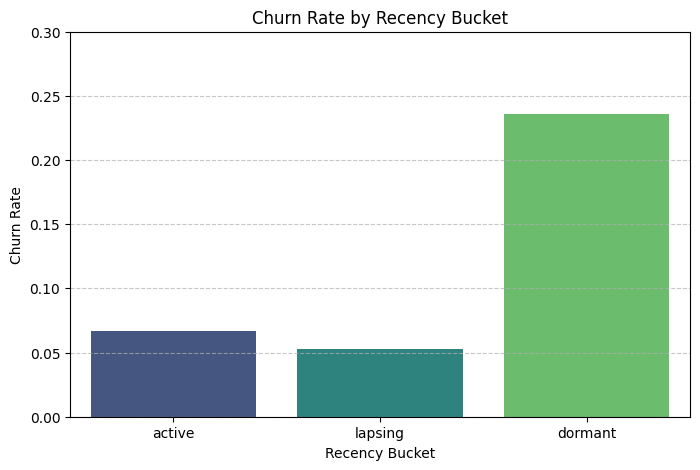

In [15]:
churn_by_recency = pd.crosstab(df['recency_bucket'], df['is_churned'], normalize='index')

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_by_recency.index, y=churn_by_recency[1], palette='viridis', hue=churn_by_recency.index, legend=False)
plt.title('Churn Rate by Recency Bucket')
plt.xlabel('Recency Bucket')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.3) # Set y-axis limit to better compare rates
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#4. Ratios & interaction features

In [16]:
# -----------------------------------------------------------
# 🔹 4A. RATIOS THAT EXPOSE BEHAVIOUR  (mind divide-by-zero!)
# -----------------------------------------------------------
# tickets per order: a dissatisfaction signal, normalised by activity
df['tickets_per_order'] = df['support_tickets'] / df['frequency'].replace(0, np.nan)
df['tickets_per_order'] = df['tickets_per_order'].fillna(0)   # 0 orders -> 0

# spend per category: concentration of spend
df['spend_per_category'] = df['monetary'] / df['n_categories'].replace(0, np.nan)
df['spend_per_category'] = df['spend_per_category'].fillna(0)
print(df[['support_tickets', 'frequency', 'tickets_per_order',
          'monetary', 'n_categories', 'spend_per_category']].head())

   support_tickets  frequency  tickets_per_order  monetary  n_categories  \
0                2        0.0                0.0      0.00           0.0   
1                1        0.0                0.0      0.00           0.0   
2                1        1.0                1.0     39.17           1.0   
3                1        1.0                1.0      2.74           1.0   
4                0        4.0                0.0    133.80           3.0   

   spend_per_category  
0                0.00  
1                0.00  
2               39.17  
3                2.74  
4               44.60  


#### 🧪 LAB EXERCISE 4 — Engagement ratio

1. Build `orders_per_month` = `frequency` ÷ (tenure in months). Compute tenure months as `(SNAPSHOT - signup_date).dt.days / 30`, and guard against zero/NaN.
2. Fill any missing/infinite values with 0.
3. Show the new column for the 5 highest-frequency customers.

In [18]:
tenure_months = (SNAPSHOT - df['signup_date']).dt.days / 30
df['orders_per_month'] = df['frequency'] / tenure_months

# 2. replace inf/NaN with 0   (hint: .replace([np.inf,-np.inf], np.nan).fillna(0))
df['orders_per_month'] = df['orders_per_month'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. top 5 by frequency
display(df.sort_values(by='frequency', ascending=False).head(5)[['customer_id', 'frequency', 'orders_per_month']])

,customer_id,frequency,orders_per_month
237,CUST00238,19.0,0.758988
812,CUST00813,18.0,1.216216
562,CUST00563,17.0,0.753323
1918,CUST01919,16.0,0.660248
1199,CUST01200,16.0,0.919540


#### Visualize Churn Rate by Orders Per Month

In [19]:
# Create bins for 'orders_per_month'
# Using quantiles to ensure a somewhat even distribution of customers in each bin
df['orders_per_month_bucket'] = pd.qcut(df['orders_per_month'], q=4, labels=['low', 'medium_low', 'medium_high', 'high'], duplicates='drop')

print("Counts per orders_per_month bucket:")
display(df['orders_per_month_bucket'].value_counts(dropna=False))

# Calculate churn rate by orders_per_month bucket
churn_by_orders_per_month = pd.crosstab(df['orders_per_month_bucket'], df['is_churned'], normalize='index')

print("\nChurn rate by orders_per_month bucket:")
display(churn_by_orders_per_month.round(2))

Counts per orders_per_month bucket:


,count
orders_per_month_bucket,
low,626
medium_low,625
high,625
medium_high,624



Churn rate by orders_per_month bucket:


is_churned,0,1
orders_per_month_bucket,,
low,0.58,0.42
medium_low,0.91,0.09
medium_high,0.90,0.10
high,0.95,0.05


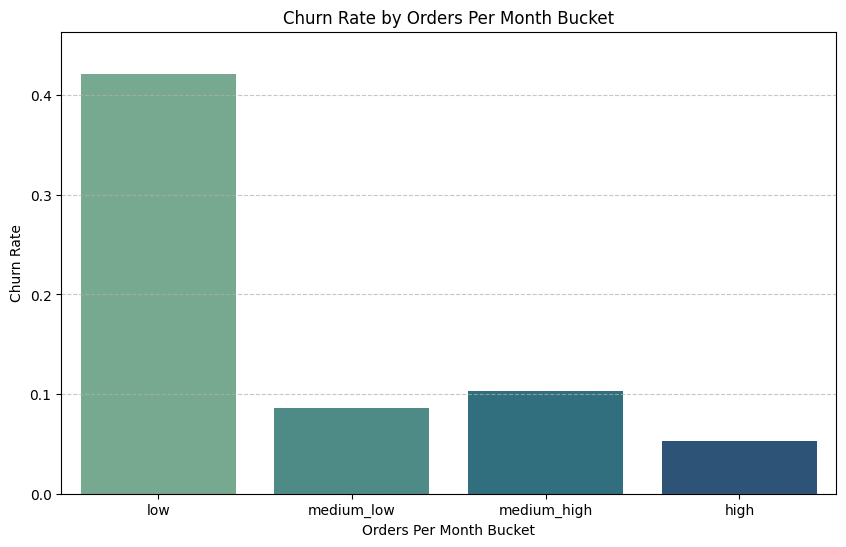

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x=churn_by_orders_per_month.index, y=churn_by_orders_per_month[1], palette='crest', hue=churn_by_orders_per_month.index, legend=False)
plt.title('Churn Rate by Orders Per Month Bucket')
plt.xlabel('Orders Per Month Bucket')
plt.ylabel('Churn Rate')
plt.ylim(0, churn_by_orders_per_month[1].max() * 1.1) # Set y-axis limit slightly above max churn rate
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#5. Datetime features

In [33]:
# -----------------------------------------------------------
# 🔹 5A. UNLOCK THE DATE COLUMNS
# -----------------------------------------------------------
df['tenure_days'] = (SNAPSHOT - df['signup_date']).dt.days   # how long a customer
df['signup_month'] = df['signup_date'].dt.month
df['signup_dow'] = df['signup_date'].dt.dayofweek            # 0=Mon
df['signup_is_weekend'] = (df['signup_dow'] >= 5).astype(int)
# cyclical encoding so Dec(12) and Jan(1) are 'close', not far apart
df['month_sin'] = np.sin(2 * np.pi * df['signup_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['signup_month'] / 12)
df[['signup_date', 'tenure_days', 'signup_month',
    'signup_dow', 'signup_is_weekend', 'month_sin', 'month_cos']].head()

,signup_date,tenure_days,signup_month,signup_dow,signup_is_weekend,month_sin,month_cos
0,2021-04-19,1168,4,0,0,8.660254e-01,-5.000000e-01
1,2023-07-31,335,7,0,0,-5.000000e-01,-8.660254e-01
2,2023-03-07,481,3,1,0,1.000000e+00,6.123234e-17
3,2022-06-18,743,6,5,1,1.224647e-16,-1.000000e+00
4,2022-06-11,750,6,5,1,1.224647e-16,-1.000000e+00


#### 🧪 LAB EXERCISE 5 — Days since first order

1. Build `days_since_first_order` = days from `first_order_date` to the `SNAPSHOT`.
2. Some customers never ordered (`first_order_date` is NaT) → fill those with 0.
3. Show the new column alongside `first_order_date` for a few rows.

In [37]:
# 1. days from first_order_date to SNAPSHOT
df['days_since_first_order'] = (SNAPSHOT - df['first_order_date']).dt.days

# 2. fill NaT-derived NaN with 0
df['days_since_first_order'] = df['days_since_first_order'].fillna(0)

# 3. show a few rows
display(df[['first_order_date', 'days_since_first_order']].head())

,first_order_date,days_since_first_order
0,NaT,0.0
1,NaT,0.0
2,2023-05-22,405.0
3,2022-07-02,729.0
4,2022-09-18,651.0


#6. Encoding categorical features

In [38]:
cols_to_encode = ['plan', 'device', 'payment_method']
# Filter out columns that are no longer present in df
existing_cols_to_encode = [col for col in cols_to_encode if col in df.columns]

if existing_cols_to_encode:
    df = pd.get_dummies(df, columns=existing_cols_to_encode,
                        drop_first=False, dtype=int)
print('columns after one-hot:', df.shape[1])
print([c for c in df.columns if c.startswith(('plan_', 'device_'))])

columns after one-hot: 61
['plan_Basic', 'plan_Premium', 'plan_Standard', 'device_Desktop', 'device_Mobile', 'device_Tablet']


In [39]:
# -----------------------------------------------------------
# 🔹 6B. FREQUENCY-ENCODE THE HIGH-CARDINALITY 'city'
# -----------------------------------------------------------
# one-hot on 17 cities would add 17 sparse columns; frequency encoding
# keeps it to ONE numeric column = how common each city is.
freq = df['city'].value_counts(normalize=True)
df['city_freq'] = df['city'].map(freq).fillna(0)
print(df[['city', 'city_freq']].drop_duplicates().head(8))

          city  city_freq
0      Chennai   0.103265
1    Hyderabad   0.130612
2         Pune   0.082857
4       Mumbai   0.169796
5        Delhi   0.165306
10   Bengaluru   0.159184
13       Patna   0.013469
14  Coimbatore   0.016735


#### 🧪 LAB EXERCISE 6 — Encode gender safely

`gender` has missing values, so handle them before encoding.
1. Fill missing `gender` with the string `'Unknown'`.
2. One-hot encode `gender` with `pd.get_dummies` (dtype=int).
3. Print the new gender columns.

In [41]:
# 1. fill missing gender with 'Unknown'
if 'gender' in df.columns:
    df['gender'] = df['gender'].fillna('Unknown')
    # 2. one-hot encode gender
    df = pd.get_dummies(df, columns=['gender'], drop_first=False, dtype=int)
    # 3. show the new columns
    print([c for c in df.columns if c.startswith('gender_')])
else:
    print("'gender' column already processed or not found.")

'gender' column already processed or not found.


#7. Rare categories & high cardinality

In [42]:
# -----------------------------------------------------------
# 🔹 7A. BUCKET RARE CITIES INTO 'Other'
# -----------------------------------------------------------
top_cities = df['city'].value_counts().head(7).index   # keep the 7 biggest
df['city_grouped'] = df['city'].where(df['city'].isin(top_cities), 'Other')
print('before:', df['city'].nunique(), 'cities')
print('after :', df['city_grouped'].nunique(), 'categories')
print(df['city_grouped'].value_counts())

before: 17 cities
after : 8 categories
city_grouped
Mumbai       416
Delhi        405
Bengaluru    390
Other        373
Hyderabad    320
Chennai      253
Pune         203
Kolkata      140
Name: count, dtype: int64


#### 🧪 LAB EXERCISE 7 — One-hot the grouped city

1. One-hot encode `city_grouped` (now only ~8 categories) with `pd.get_dummies`.
2. Print how many new columns that produced.
3. In a comment, explain why grouping first is better than one-hot on all 17 raw cities.

In [43]:
# 1. one-hot city_grouped
df = pd.get_dummies(df, columns=['city_grouped'], drop_first=False, dtype=int)

# 2. number of new city_grouped_* columns
new_city_cols = [c for c in df.columns if c.startswith('city_grouped_')]
print(f"Number of new 'city_grouped_' columns: {len(new_city_cols)}")
print(new_city_cols)

# 3. Why group first:
# Grouping rare cities into an 'Other' category before one-hot encoding helps manage high-cardinality features.
# Directly one-hot encoding all 17 raw cities would create 17 new columns, many of which would be very sparse (mostly zeros)
# due to rare cities. This increases the dimensionality of the dataset unnecessarily, can lead to overfitting
# (especially if rare cities are predictive purely by chance), and makes the model harder to interpret.
# Grouping reduces the number of columns and concentrates the signal from less frequent categories, leading to a more efficient and robust model.

Number of new 'city_grouped_' columns: 16
['city_grouped_Bengaluru', 'city_grouped_Chennai', 'city_grouped_Delhi', 'city_grouped_Hyderabad', 'city_grouped_Kolkata', 'city_grouped_Mumbai', 'city_grouped_Other', 'city_grouped_Pune', 'city_grouped_Bengaluru', 'city_grouped_Chennai', 'city_grouped_Delhi', 'city_grouped_Hyderabad', 'city_grouped_Kolkata', 'city_grouped_Mumbai', 'city_grouped_Other', 'city_grouped_Pune']


#8. Domain-driven features

In [44]:
# -----------------------------------------------------------
# 🔹 8A. ENCODE BUSINESS KNOWLEDGE AS FEATURES
# -----------------------------------------------------------
# a 'dormant' flag: no orders, or very stale
df['is_dormant'] = ((df['frequency'] == 0) | (df['recency_days'] > 180)).astype(int)
# a simple RFM score: rank each of R, F, M into 1-4 and combine
df['R_score'] = pd.qcut(-df['recency_days'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['F_score'] = pd.qcut(df['frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['M_score'] = pd.qcut(df['monetary'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['rfm_score'] = df['R_score'] + df['F_score'] + df['M_score']   # 3..12
print(df[['recency_days', 'frequency', 'monetary', 'rfm_score', 'is_dormant']].head())
print('\nMean churn by RFM score:')
print(df.groupby('rfm_score')['is_churned'].mean().round(2))

   recency_days  frequency  monetary  rfm_score  is_dormant
0        9999.0        0.0      0.00          3           1
1        9999.0        0.0      0.00          3           1
2         405.0        1.0     39.17          5           1
3         729.0        1.0      2.74          3           1
4          15.0        4.0    133.80         10           0

Mean churn by RFM score:
rfm_score
3     0.58
4     0.19
5     0.13
6     0.09
7     0.07
8     0.10
9     0.08
10    0.08
11    0.04
12    0.05
Name: is_churned, dtype: float64


#### 🧪 LAB EXERCISE 8 — Invent a feature for the business

1. Build `high_value` = 1 when a customer is in the **top 20%** of `monetary`, else 0 (hint: compare to `df['monetary'].quantile(0.8)`).
2. Compare the churn rate of high-value vs the rest with a `groupby`.
3. In a comment, suggest one *more* domain feature you'd add and why.

In [45]:
# 1. high_value flag (top 20% of monetary)
monetary_80_percentile = df['monetary'].quantile(0.8)
df['high_value'] = (df['monetary'] > monetary_80_percentile).astype(int)

# 2. churn rate by high_value
print("Churn rate by high_value customer status:")
display(df.groupby('high_value')['is_churned'].mean().round(2))

# 3. Another domain feature I'd add: a 'seasonal_spender' flag. This would indicate if a customer tends to make purchases during specific seasons or holidays. This could be useful for targeted marketing campaigns and predicting purchase intent during peak times.

Churn rate by high_value customer status:


,is_churned
high_value,
0,0.19
1,0.05


#9. Assemble the feature matrix — and check for leakage

**Leakage check:** a feature must only use information available *at prediction time*. Drop IDs, raw dates and the target itself; keep engineered numerics.

In [46]:
# -----------------------------------------------------------
# 🔹 9A. BUILD X (features) AND y (target)
# -----------------------------------------------------------
drop_cols = ['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'city', 'gender', 'age_group', 'city_grouped', 'is_churned']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
X = X.select_dtypes(include='number')   # keep numeric features only
y = df['is_churned']
print('Feature matrix:', X.shape)
print('All numeric? ', X.select_dtypes(exclude='number').empty)
print('Any missing? ', int(X.isna().sum().sum()))
print('\nEngineered features include:')
print([c for c in X.columns if c in ('monetary_log','recency_days','rfm_score',
       'tickets_per_order','tenure_days','city_freq','is_dormant')])

Feature matrix: (2500, 61)
All numeric?  True
Any missing?  1349

Engineered features include:
['recency_days', 'monetary_log', 'tickets_per_order', 'is_dormant', 'rfm_score', 'tenure_days', 'city_freq']


#### 🧪 LAB EXERCISE 9 — Sanity-check & sniff for leakage

1. Fill any remaining missing values in `X` (e.g. `age`) with the column median.
2. Print the correlation of each feature with `y`, sorted — the strongest are your best predictors.
3. In a comment, name one feature that would be **leakage** if it existed (a value you could only know *after* a customer churned).

In [48]:
# 1. fill any remaining missing values with the median
X.fillna(X.median(), inplace=True)

# 2. correlation of each feature with y, sorted
print("Correlation of features with 'is_churned':\n")
display(X.assign(churn=y).corr()['churn'].drop('churn').sort_values())

# 3. A feature that would be leakage:
# A feature like 'customer_service_complaints_after_cancellation' would be leakage,
# as these complaints could only occur after the customer has churned (cancelled their service).
# Any feature that contains information about the future or about the outcome being predicted
# that would not be available at the time of prediction is a leakage feature.

Correlation of features with 'is_churned':



,churn
aov_log,-0.488545
monetary_log,-0.474965
rfm_score,-0.385565
n_categories,-0.355871
R_score,-0.346636
...,...
city_grouped_Hyderabad,0.031792
tenure_days,0.038022
support_tickets,0.068880
is_dormant,0.310526


### Split the data into training and testing sets

In [50]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2000, 61)
X_test shape: (500, 61)
y_train shape: (2000,)
y_test shape: (500,)


### Train a Random Forest Classifier

In [52]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# Using a random_state for reproducibility
model = RandomForestClassifier(random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


### Visualize Feature Importances

/tmp/ipykernel_809/259096762.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')


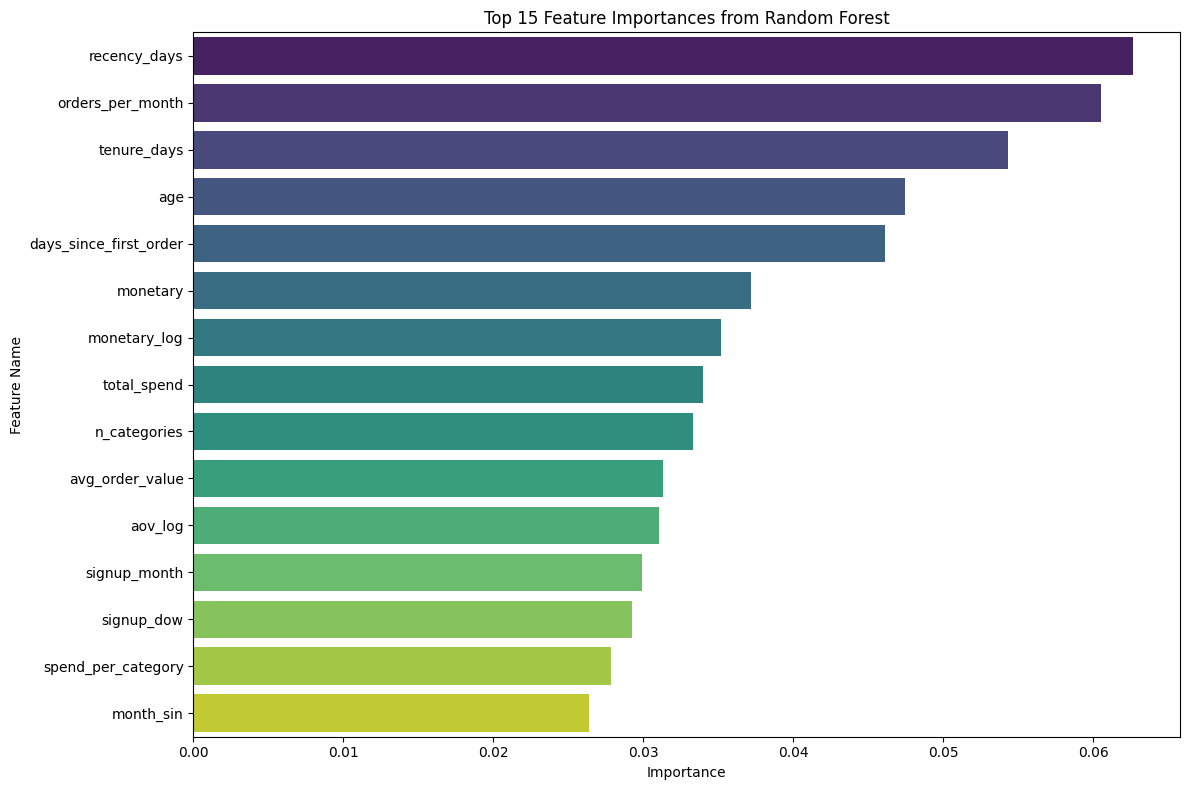

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the top 15 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Generate and Visualize Confusion Matrix

<Figure size 800x600 with 0 Axes>

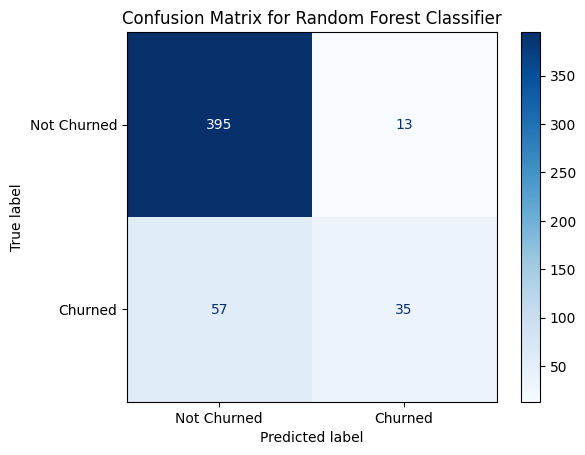

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned', 'Churned'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.grid(False) # Turn off grid for confusion matrix
plt.show()

### Calculate ROC-AUC Score

In [56]:
from sklearn.metrics import roc_auc_score

# Get predicted probabilities for the positive class (churned)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.7740


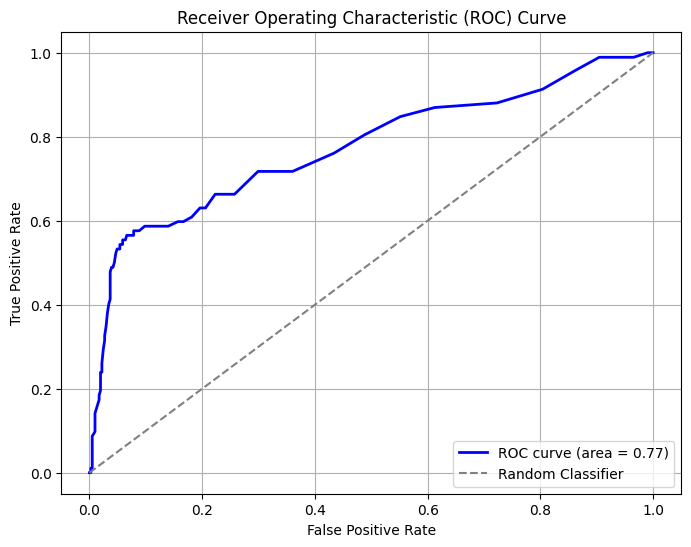

In [57]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The ROC curve has been plotted and displayed. This curve visualizes the trade-off between the True Positive Rate (sensitivity) and the False Positive Rate (1-specificity) at various threshold settings. The closer the curve is to the top-left corner, the better the model's performance. The area under this curve (ROC-AUC) was previously calculated as 0.77, which aligns with the visual representation of the curve being well above the diagonal 'Random Classifier' line, indicating good discriminative power.

In [58]:
from sklearn.metrics import precision_score, recall_score

# Calculate Precision
precision = precision_score(y_test, y_pred)

# Calculate Recall
recall = recall_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.7292
Recall: 0.3804


The precision and recall metrics for your Random Forest model are:

Precision: 0.7292
Recall: 0.3804
Precision (0.7292) tells us that when the model predicts a customer will churn, it is correct about 72.92% of the time. This means there are relatively few false positives (customers predicted to churn who actually don't).

Recall (0.3804) indicates that the model correctly identifies 38.04% of all actual churners. This means the model is missing a significant number of customers who do churn (high number of false negatives).

Depending on your business goals (e.g., minimizing false alarms vs. catching as many churners as possible), you might prioritize one metric over the other. For churn prediction, a higher recall is often desired to identify more at-risk customers, even if it means some false positives.

In [59]:
from sklearn.metrics import f1_score

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

print(f"F1-Score: {f1:.4f}")

F1-Score: 0.5000


The F1-score for your model is 0.5000.

The F1-score is the harmonic mean of precision and recall. It provides a single metric that balances both, which is particularly useful when you have imbalanced classes (like churn prediction) or when both false positives and false negatives are important. An F1-score of 0.5000 suggests that while your model has reasonable precision (0.7292), its low recall (0.3804) pulls down the overall F1-score, indicating that there's room for improvement in identifying a higher proportion of actual churners.

#📘 Summary — from raw data to a feature matrix

| Technique | What you built | Key calls |
| --------- | -------------- | --------- |
| **Aggregation (RFM)** | recency, frequency, monetary | `groupby().agg()` · merge |
| **Log transform** | `monetary_log` (skew fixed) | `np.log1p` |
| **Binning** | `age_group`, recency buckets | `pd.cut` |
| **Ratios** | tickets/order, orders/month | divide + guard zero |
| **Datetime** | tenure, recency, cyclical month | `.dt` · `sin/cos` |
| **Encoding** | one-hot + `city_freq` | `get_dummies` · frequency map |
| **Rare grouping** | `city_grouped` | `.where(isin(top), 'Other')` |
| **Domain** | `rfm_score`, `is_dormant`, `high_value` | business logic |

You started with raw customers + transactions and finished with a **clean, numeric, leak-free feature matrix** ready for a churn model.

**Next — U10 Part 2:** feature *selection* (keep what helps), feature *extraction* (PCA, embeddings) and dimensionality reduction.